In [1]:
from entsoe import EntsoePandasClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.patches as mpatches

# loading data

In [2]:
with open("data/api_key.txt", "r") as f:
    api_key = f.read().strip()
    
client = EntsoePandasClient(api_key=api_key)
start = pd.Timestamp('20240101', tz='UTC')
end = pd.Timestamp('20251230', tz='UTC')
country_code = 'FR' 

FileNotFoundError: [Errno 2] No such file or directory: 'data/api_key.txt'

In [ ]:
loads = client.query_load_and_forecast(country_code, start=start, end=end)
wind_solar_forecast = client.query_wind_and_solar_forecast(country_code, start=start, end=end, psr_type=None)
actual_wind_solar = client.query_generation(country_code, start=start, end=end, psr_type=None)
actual_wind_solar = actual_wind_solar[[("Solar","Actual Aggregated"),("Wind Offshore","Actual Aggregated"),("Wind Onshore","Actual Aggregated")]]
actual_wind_solar.columns = actual_wind_solar.columns.map('_'.join)

1
2


Connection Error, retrying in 10 seconds


KeyboardInterrupt: 

In [3]:
df = loads.join(wind_solar_forecast, how='inner')
df = df.join(actual_wind_solar, how='inner')
df.columns = ["DA_load","actual_load","DA_solar","DA_offshore","DA_onshore","actual_solar","actual_offshore","actual_onshore"]
df["DA_wind"] = df["DA_offshore"].fillna(0) + df["DA_onshore"].fillna(0)
df["actual_wind"] = df["actual_offshore"].fillna(0) + df["actual_onshore"].fillna(0)                                                    # fill with zero, discutable choice but we ball
df["net_load"] = df["actual_load"]-df["actual_solar"]-df["actual_wind"]
df = df[["net_load","DA_load","actual_load","DA_solar","DA_wind","actual_solar","actual_wind"]]
df = df.asfreq('h')                                                                                                                     #fill every period (useful for lagged input)

NameError: name 'loads' is not defined

In [ ]:
loads.to_csv('data/loads.csv', index=True)
wind_solar_forecast.to_csv('data/wind_solar_forecast.csv', index=True)
actual_wind_solar.to_csv('data/actual_wind_solar.csv', index=True)
df.to_csv('data/df.csv', index=True)

Chargement des données 

In [4]:
df = pd.read_csv("data/df.csv")
df['Unnamed: 0'] = pd.to_datetime(df['Unnamed: 0'])
df.set_index('Unnamed: 0', inplace=True)
df.index = pd.to_datetime(df.index, utc=True)
df = df["2024-01-01":]

/tmp/ipykernel_12042/4132042765.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Unnamed: 0'] = pd.to_datetime(df['Unnamed: 0'])


In [31]:
df.columns

Index(['net_load', 'DA_load', 'actual_load', 'DA_solar', 'DA_wind',
       'actual_solar', 'actual_wind', 'net_load_24', 'net_load_25',
       'net_load_26', 'DA_renewable', 'DA_renewable_1', 'DA_renewable_2',
       'DA_renewable_3', 'DA_load_1', 'DA_load_2', 'DA_load_3', 'hour_sin',
       'hour_cos'],
      dtype='object')

[]

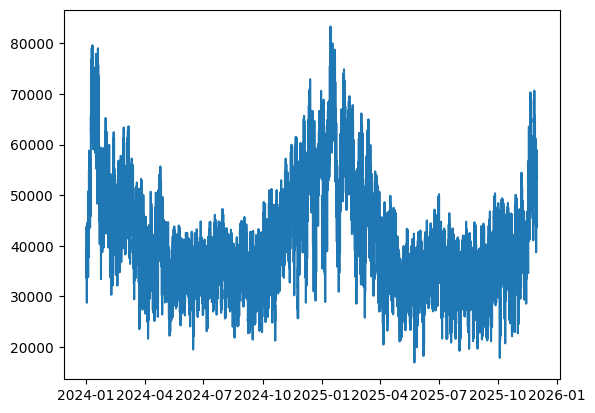

In [ ]:
plt.plot(df['net_load'])
plt.plot()
# ✅ Save figure
plt.savefig(
    ".png",
    dpi=300,
    bbox_inches="tight"
)

Pour les lagged net load,on ne peut pas utiliser les 23 premières lagged value parce qu'on doit faire du Day Ahead forecasting donc on fait du forecasting avec 24 heure d'avance. On peut cependant conserver lesgged value 24,25,26.

0

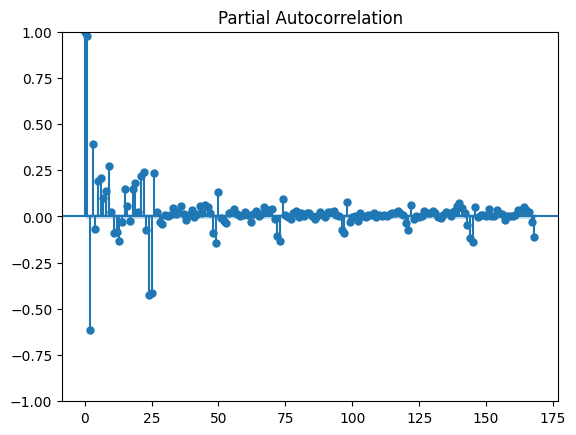

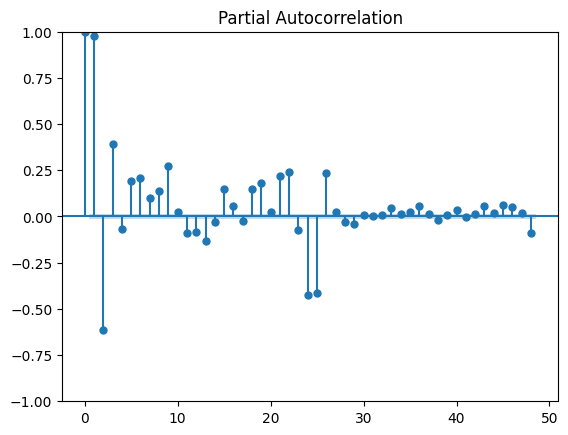

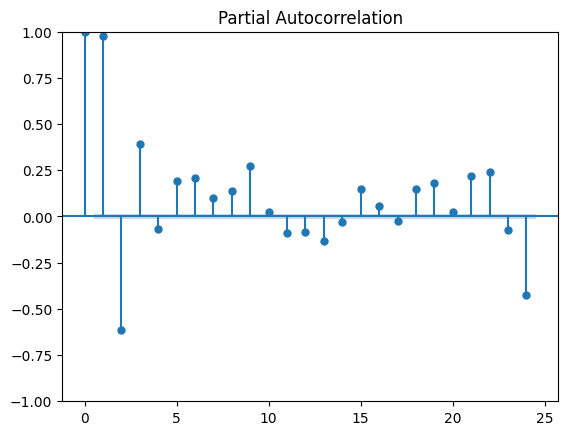

In [6]:
plot_pacf(df['net_load'].dropna(), lags=168)    #a week
plot_pacf(df['net_load'].dropna(), lags=48)     #2 days
plot_pacf(df['net_load'].dropna(), lags=24)     #1 days
0

In [7]:
#create input feature
df["net_load_24"] = df["net_load"].shift(24)
df["net_load_25"] = df["net_load"].shift(25)
df["net_load_26"] = df["net_load"].shift(26)

df["DA_renewable"] = df["DA_solar"] + df["DA_wind"]
df["DA_renewable_1"] = df["DA_renewable"].shift(1)
df["DA_renewable_2"] = df["DA_renewable"].shift(2)
df["DA_renewable_3"] = df["DA_renewable"].shift(3)

df["DA_load_1"] = df["DA_load"].shift(1)
df["DA_load_2"] = df["DA_load"].shift(2)
df["DA_load_3"] = df["DA_load"].shift(3)

hours = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * hours / 24)
df['hour_cos'] = np.cos(2 * np.pi * hours / 24)

input_features = ["net_load_24","net_load_25","net_load_26","DA_renewable","DA_renewable_1","DA_renewable_2","DA_renewable_3","DA_load","DA_load_2","hour_sin","hour_cos"] #"DA_load","DA_load_1","DA_load_2","DA_load_3" A METTRE ?

# regression

In [8]:
df_train = df[:'2024-12-31']
df_test = df['2025-01-01':]

In [9]:
df_clean = df_train.dropna(subset=['net_load'] + input_features)

In [10]:
n = 19
quantiles = np.linspace(1/(n+1), n/(n+1), n) # 0.05, 0.10, ..., 0.95
formula = f"net_load ~ {' + '.join(input_features)} + 0"
quantile_models = {}
quantile_reg = {}

ATTENTION: LORSQU'ON FERA LE TEST SUR UNE AUTRE PERIODE IL FAUDRA AVOIR ENREGISTRER LES res DANS UN DICTIONNAIRE OU SIMILAIRE POUR POUVOIR APPLIQUER LES QUANTILE REGRESSION SUR LE DATA SET

In [11]:
for q in quantiles:
    q_round = round(q, 2)
    res = smf.quantreg(formula, data=df_clean).fit(q=q,max_iter=500
                                                   )       #ATTENTION il va falloir choisr lesinput features parce que la j'ai tout mis...
    quantile_reg[q_round] = res
    quantile_models[q_round] = res.predict(df_clean)

/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: Iter

In [12]:
pred_df = pd.DataFrame(quantile_models, index=df_clean.index)
is_monotonic = (pred_df.diff(axis=1).iloc[:, 1:] >= 0).all(axis=1)      #verifie que cdf croissante
is_monotonic.mean()

np.float64(0.9802353478807266)

In [13]:
sorted_pred_matrix = np.sort(pred_df.values, axis=1)

def get_cdf_value(y_observed, quantile_row):
    # i/n logic based on your specific formula
    idx = np.searchsorted(quantile_row, y_observed)
    return idx / n

df_clean['cdf_value'] = [get_cdf_value(y, row) for y, row in zip(df_clean['net_load'], sorted_pred_matrix)]

/tmp/ipykernel_12042/61424172.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['cdf_value'] = [get_cdf_value(y, row) for y, row in zip(df_clean['net_load'], sorted_pred_matrix)]


## application on test

In [14]:
df_test_clean = df_test.dropna(subset=['net_load'] + input_features)
quantile_models = {}

In [15]:
for q in quantiles:
    q_round = round(q, 2)
    model_q = quantile_reg[q_round]
    quantile_models[q_round] = model_q.predict(df_test_clean)

In [16]:
quantile_reg[0.65].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:               net_load   Pseudo R-squared:               0.8298
Model:                       QuantReg   Bandwidth:                       333.4
Method:                 Least Squares   Sparsity:                        3976.
Date:                Thu, 22 Jan 2026   No. Observations:                 8753
Time:                        14:08:51   Df Residuals:                     8742
                                        Df Model:                           11
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
net_load_24        0.2838      0.014     19.832      0.000       0.256       0.312
net_load_25       -0.1626      0.023     -7.032      0.000      -0.208      -0.117
net_load_26       -0.0700      0.016     -4.410      0.000      -0.101      -0.039
DA_renewable      -1.0466      0.039    -26.719      0.000      -1.123      -0.970
DA_renewable_1     0.4886      0.087      5.595      0.000       0.317       0.660
DA_renewable_2    -0.4784      0.089     -5.399      0.000      -0.652      -0.305
DA_renewable_3     0.1862      0.040      4.636      0.000       0.108       0.265
DA_load            0.8152      0.010     79.887      0.000       0.795       0.835
DA_load_2          0.1377      0.010     13.546      0.000       0.118       0.158
hour_sin         168.4898     41.708      4.040      0.000      86.732     250.248
hour_cos          64.7457     38.266      1.692      0.091     -10.265     139.756
==================================================================================

The condition number is large, 2.3e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
pred_df

,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95
Unnamed: 0,,,,,,,,,,,,,,,,,,,
2024-01-02 03:00:00+00:00,25361.076038,26072.015331,26406.036020,26773.587342,27070.147534,27442.783384,27656.487377,27947.008362,28201.732805,28499.465917,28746.126921,28990.994732,29339.806479,29618.646895,29929.883889,30185.313080,31204.107221,32091.670453,33477.229839
2024-01-02 04:00:00+00:00,26324.969527,26822.892680,26997.602048,27122.207064,27226.917602,27543.399183,27650.127055,27825.397503,28091.494207,28301.549129,28503.007633,28743.994891,29069.979233,29369.775803,29706.021030,29953.441314,30881.378144,31747.769109,33235.790720
2024-01-02 05:00:00+00:00,26828.790930,27426.304822,27706.338302,28103.583289,28390.417333,28755.616710,28981.429464,29287.021114,29575.814742,29875.678226,30178.167489,30494.206210,30827.598647,31121.288307,31526.826098,31946.932632,32861.402860,33789.343681,35286.916108
2024-01-02 06:00:00+00:00,29209.864983,29881.322339,30231.699969,30717.692219,31060.060013,31436.431050,31711.368655,32059.359201,32370.350579,32703.026743,33048.871678,33404.811711,33738.769462,34041.901685,34482.548722,34973.154457,35854.180891,36810.421586,38298.023756
2024-01-02 07:00:00+00:00,31233.747109,31954.913360,32294.294833,32781.337270,33125.837269,33504.033410,33795.080110,34145.361897,34467.757954,34802.469320,35149.662362,35510.124363,35854.158186,36160.069746,36620.090309,37120.807770,37996.234445,38969.391915,40438.105302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00+00:00,53319.743962,54060.714164,54474.159666,54627.674785,54809.346207,55072.873446,55254.644334,55467.589922,55712.553741,55925.773665,56217.408947,56501.814691,56788.859640,57113.919264,57483.339251,58003.107158,58333.676997,59066.229512,60249.886766
2024-12-31 20:00:00+00:00,49671.970884,50436.208356,50852.084368,51156.127134,51443.775989,51739.740819,51979.690611,52260.427094,52490.694894,52746.623213,53054.005554,53326.946544,53627.166071,53922.538177,54288.236551,54793.585866,55245.509378,55995.744085,57153.874758
2024-12-31 21:00:00+00:00,48663.117453,49545.386509,50106.853136,50476.116031,50826.570664,51150.476001,51403.414233,51712.683339,51933.308776,52218.311654,52526.992299,52800.686472,53104.798036,53404.617574,53726.005108,54189.029221,54694.826681,55422.660309,56574.146087


In [18]:
pred_df = pd.DataFrame(quantile_models, index=df_test_clean.index)
is_monotonic = (pred_df.diff(axis=1).iloc[:, 1:] >= 0).all(axis=1)      #verifie que cdf croissante
is_monotonic.mean()

np.float64(0.9523392544408307)

In [19]:
sorted_pred_test_matrix = np.sort(pred_df.values, axis=1)

def get_cdf_value(y_observed, quantile_row):
    # i/n logic based on your specific formula
    idx = np.searchsorted(quantile_row, y_observed)
    return idx / n

df_test_clean['cdf_value'] = [get_cdf_value(y, row) for y, row in zip(df_test_clean['net_load'], sorted_pred_test_matrix)]

/tmp/ipykernel_12042/1694558448.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_clean['cdf_value'] = [get_cdf_value(y, row) for y, row in zip(df_test_clean['net_load'], sorted_pred_test_matrix)]


In [20]:
df_test_clean

,net_load,DA_load,actual_load,DA_solar,DA_wind,actual_solar,actual_wind,net_load_24,net_load_25,net_load_26,DA_renewable,DA_renewable_1,DA_renewable_2,DA_renewable_3,DA_load_1,DA_load_2,DA_load_3,hour_sin,hour_cos,cdf_value
Unnamed: 0,,,,,,,,,,,,,,,,,,,,
2025-01-01 04:00:00+00:00,43728.28,54000.0,56088.90,0.00,12281.91000,0.00,12360.62,56431.19,54896.95,55986.42,12281.91000,11940.11000,11729.30000,11516.09000,55200.0,57800.0,61300.0,0.866025,5.000000e-01,0.421053
2025-01-01 05:00:00+00:00,43516.78,53500.0,56391.92,0.00,12624.21000,0.00,12875.14,59078.27,56431.19,54896.95,12624.21000,12281.91000,11940.11000,11729.30000,54000.0,55200.0,57800.0,0.965926,2.588190e-01,0.473684
2025-01-01 06:00:00+00:00,43311.93,54100.0,56883.97,0.00,12964.71000,0.00,13572.04,61520.43,59078.27,56431.19,12964.71000,12624.21000,12281.91000,11940.11000,53500.0,54000.0,55200.0,1.000000,6.123234e-17,0.421053
2025-01-01 07:00:00+00:00,42825.64,54400.0,57114.11,0.00,13755.16000,318.43,13970.04,63229.69,61520.43,59078.27,13755.16000,12964.71000,12624.21000,12281.91000,54100.0,53500.0,54000.0,0.965926,-2.588190e-01,0.473684
2025-01-01 08:00:00+00:00,41823.12,54200.0,57232.74,451.01,14543.86000,802.07,14607.55,64152.43,63229.69,61520.43,14994.87000,13755.16000,12964.71000,12624.21000,54400.0,54100.0,53500.0,0.866025,-5.000000e-01,0.526316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30 19:00:00+00:00,57286.50,61700.0,61486.37,0.00,3606.27368,0.00,4199.87,50698.40,50793.34,48424.87,3606.27368,3573.41626,3391.37246,3951.42608,63600.0,59800.0,56000.0,-0.965926,2.588190e-01,0.421053
2025-11-30 20:00:00+00:00,54625.30,59300.0,59348.66,0.00,3736.94751,0.00,4723.36,48951.10,50698.40,50793.34,3736.94751,3606.27368,3573.41626,3391.37246,61700.0,63600.0,59800.0,-0.866025,5.000000e-01,0.263158
2025-11-30 21:00:00+00:00,53425.90,57200.0,58647.79,0.00,4050.76489,0.00,5221.89,50143.85,48951.10,50698.40,4050.76489,3736.94751,3606.27368,3573.41626,59300.0,61700.0,63600.0,-0.707107,7.071068e-01,0.368421


### verification

Bonne probabilistic calibration

ON TRAIN

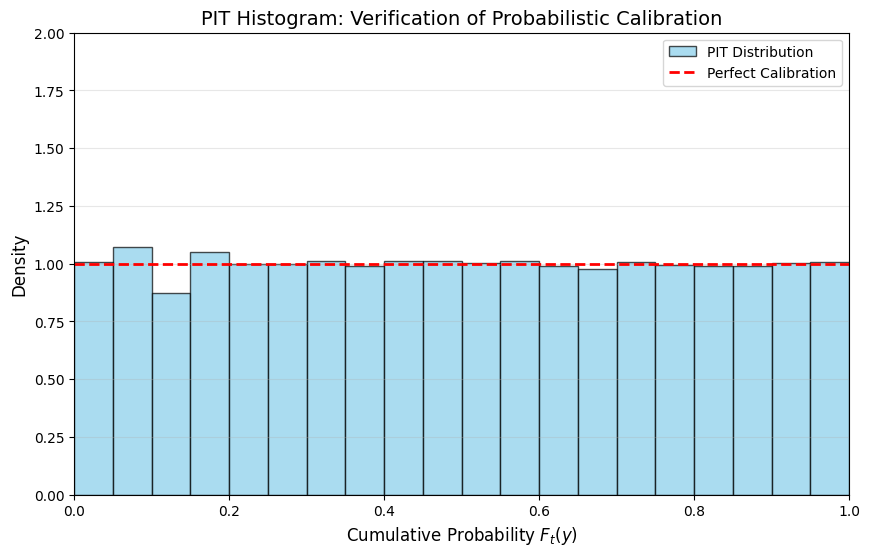

In [21]:
# 1. Create the plot
plt.figure(figsize=(10, 6))
n_bins = 20 # Typically matches or slightly exceeds your 'n' quantiles

# 2. Plot the distribution of your CDF values
plt.hist(df_clean["cdf_value"], bins=n_bins, density=True, 
         color='skyblue', edgecolor='black', alpha=0.7, label='PIT Distribution')

# 3. Add the theoretical Uniform(0,1) line
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Perfect Calibration')

# 4. Formatting
plt.title("PIT Histogram: Verification of Probabilistic Calibration", fontsize=14)
plt.xlabel("Cumulative Probability $F_t(y)$", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 2) # Helps visualize deviations from the 1.0 line
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

ON TEST

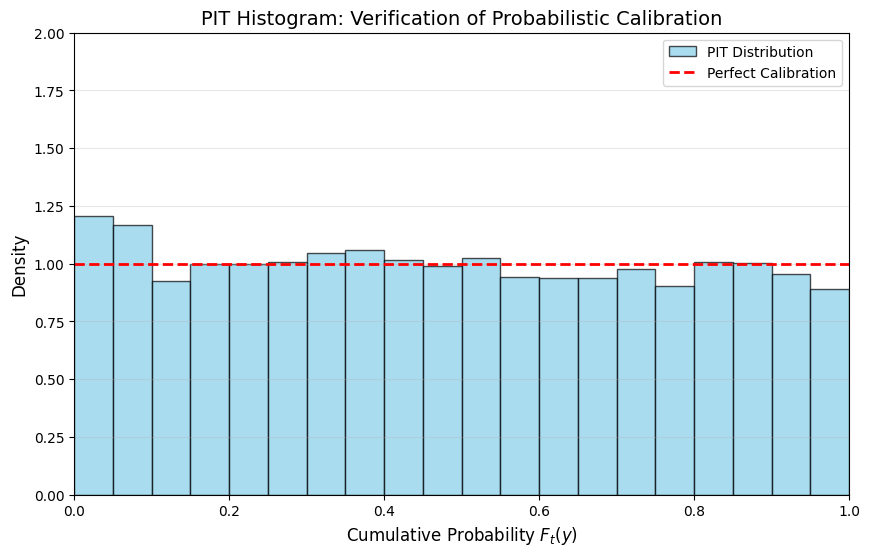

In [22]:
# 1. Create the plot
plt.figure(figsize=(10, 6))
n_bins = 20 # Typically matches or slightly exceeds your 'n' quantiles

# 2. Plot the distribution of your CDF values
plt.hist(df_test_clean["cdf_value"], bins=n_bins, density=True, 
         color='skyblue', edgecolor='black', alpha=0.7, label='PIT Distribution')

# 3. Add the theoretical Uniform(0,1) line
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Perfect Calibration')

# 4. Formatting
plt.title("PIT Histogram: Verification of Probabilistic Calibration", fontsize=14)
plt.xlabel("Cumulative Probability $F_t(y)$", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 2) # Helps visualize deviations from the 1.0 line
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

marginally calibrated A FAIRE

### jolie graphique

ON TRAIN

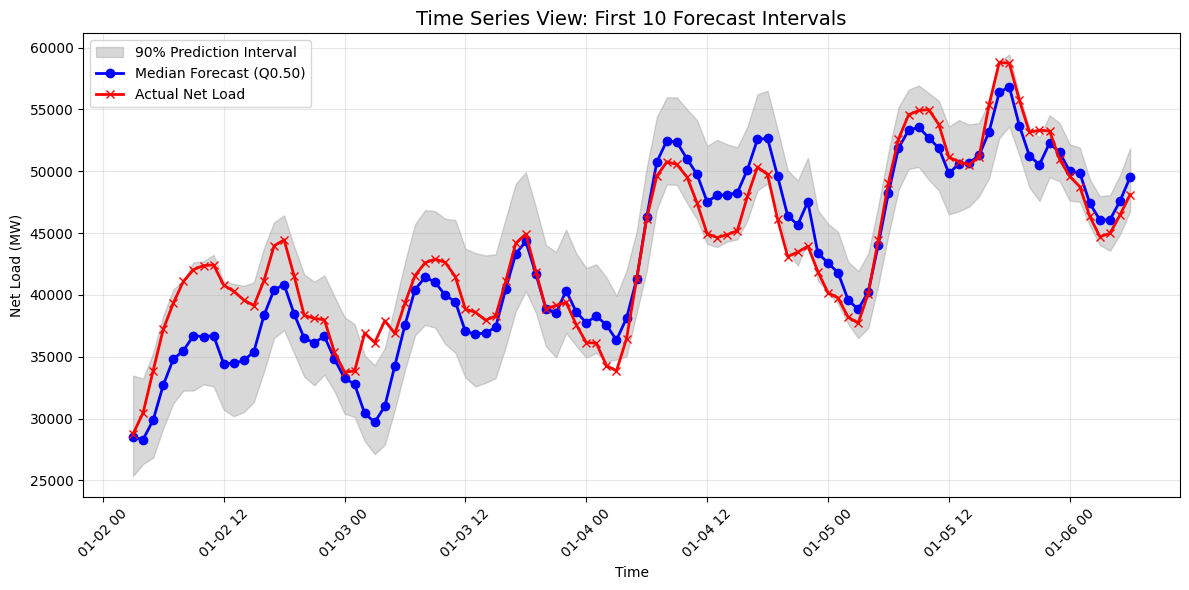

In [23]:
L=100
# 1. Select the first L rows
df_plot = df_clean.head(L).copy()
# Extract the corresponding L rows from your sorted prediction matrix
# (Assuming sorted_pred_matrix was built from df_clean)
preds_plot = sorted_pred_matrix[:L, :]

# 2. Extract specific quantiles for plotting
# index 0  -> 0.05 (Lower Bound)
# index 9  -> 0.50 (Median)
# index 18 -> 0.95 (Upper Bound)
q_low = preds_plot[:, 0]
q_med = preds_plot[:, 9]
q_high = preds_plot[:, 18]

# 3. Plotting
plt.figure(figsize=(12, 6))

# Plot the 90% Prediction Interval (The "Cloud")
plt.fill_between(df_plot.index, q_low, q_high, color='gray', alpha=0.3, label='90% Prediction Interval')

# Plot the Median Forecast
plt.plot(df_plot.index, q_med, color='blue', marker='o', label='Median Forecast (Q0.50)', linewidth=2)

# Plot the Actual Observed Net Load
plt.plot(df_plot.index, df_plot['net_load'], color='red', marker='x', label='Actual Net Load', linewidth=2)

# 4. Formatting
plt.title("Time Series View: First 10 Forecast Intervals", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Net Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

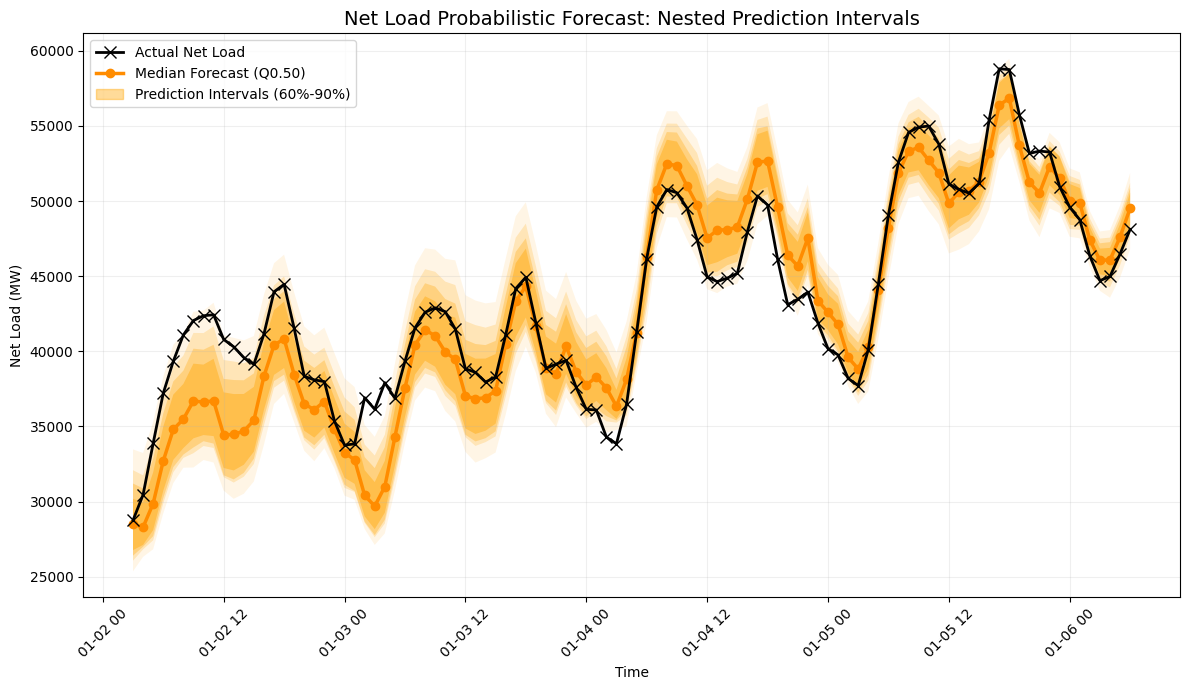

In [24]:
L=100

# 1. Select the first L rows
df_plot = df_clean.head(L).copy()
preds_plot = sorted_pred_matrix[:L, :]

plt.figure(figsize=(12, 7))

# 2. Define the intervals we want to show and their indices in your 19-quantile matrix
# Indices for 19 quantiles: 0=0.05, 1=0.10, 2=0.15, 3=0.20, ... 9=0.50 ... 18=0.95
intervals = [
    (0, 18, 0.1, '90% Interval'), # Q0.05 to Q0.95
    (1, 17, 0.2, '80% Interval'), # Q0.10 to Q0.90
    (2, 16, 0.3, '70% Interval'), # Q0.15 to Q0.85
    (3, 15, 0.4, '60% Interval'), # Q0.20 to Q0.80
]

# 3. Plot the Intervals (shaded from widest/lightest to narrowest/darkest)
for low_idx, high_idx, alpha, label in intervals:
    plt.fill_between(
        df_plot.index, 
        preds_plot[:, low_idx], 
        preds_plot[:, high_idx], 
        color='orange', 
        alpha=alpha, 
        edgecolor=None
    )

# 4. Plot the Median (Q0.50 is index 9)
plt.plot(df_plot.index, preds_plot[:, 9], color='darkorange', marker='o', 
         label='Median Forecast (Q0.50)', linewidth=2.5)

# 5. Plot the Actual Observed Net Load
plt.plot(df_plot.index, df_plot['net_load'], color='black', marker='x', 
         label='Actual Net Load', linewidth=2, markersize=8)

# 6. Formatting
plt.title("Net Load Probabilistic Forecast: Nested Prediction Intervals", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Net Load (MW)")

# Custom Legend to show the orange shades
orange_patch = mpatches.Patch(color='orange', alpha=0.4, label='Prediction Intervals (60%-90%)')
plt.legend(handles=[plt.gca().get_legend_handles_labels()[0][1], 
                    plt.gca().get_legend_handles_labels()[0][0], 
                    orange_patch])

plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ON TEST

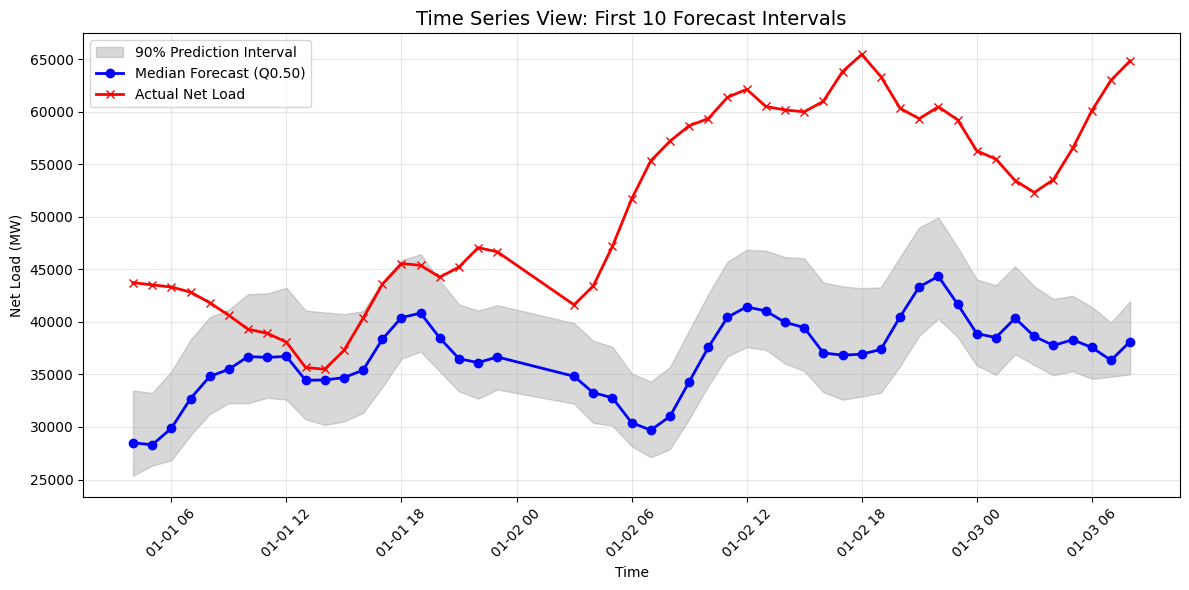

In [25]:
L=50
# 1. Select the first L rows
df_plot = df_test_clean.head(L).copy()
# Extract the corresponding L rows from your sorted prediction matrix
# (Assuming sorted_pred_matrix was built from df_test_clean)
preds_plot = sorted_pred_matrix[:L, :]

# 2. Extract specific quantiles for plotting
# index 0  -> 0.05 (Lower Bound)
# index 9  -> 0.50 (Median)
# index 18 -> 0.95 (Upper Bound)
q_low = preds_plot[:, 0]
q_med = preds_plot[:, 9]
q_high = preds_plot[:, 18]

# 3. Plotting
plt.figure(figsize=(12, 6))

# Plot the 90% Prediction Interval (The "Cloud")
plt.fill_between(df_plot.index, q_low, q_high, color='gray', alpha=0.3, label='90% Prediction Interval')

# Plot the Median Forecast
plt.plot(df_plot.index, q_med, color='blue', marker='o', label='Median Forecast (Q0.50)', linewidth=2)

# Plot the Actual Observed Net Load
plt.plot(df_plot.index, df_plot['net_load'], color='red', marker='x', label='Actual Net Load', linewidth=2)

# 4. Formatting
plt.title("Time Series View: First 10 Forecast Intervals", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Net Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

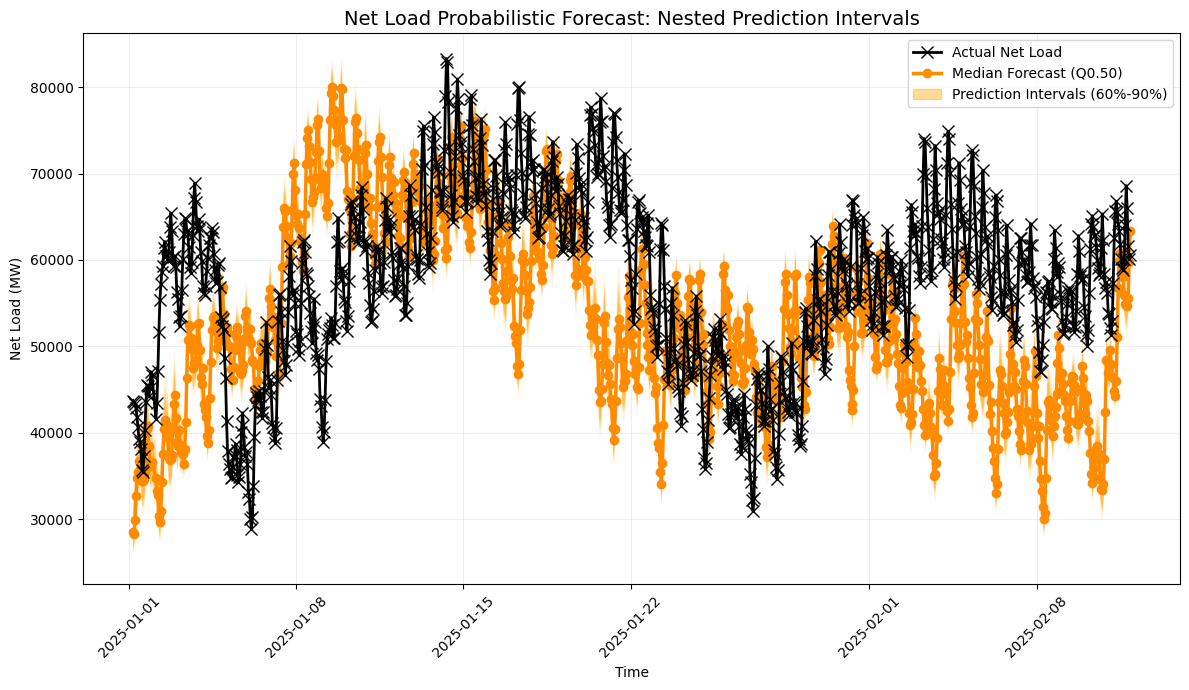

In [26]:
L=1000

# 1. Select the first L rows
df_plot = df_test_clean.head(L).copy()
preds_plot = sorted_pred_matrix[:L, :]

plt.figure(figsize=(12, 7))

# 2. Define the intervals we want to show and their indices in your 19-quantile matrix
# Indices for 19 quantiles: 0=0.05, 1=0.10, 2=0.15, 3=0.20, ... 9=0.50 ... 18=0.95
intervals = [
    (0, 18, 0.1, '90% Interval'), # Q0.05 to Q0.95
    (1, 17, 0.2, '80% Interval'), # Q0.10 to Q0.90
    (2, 16, 0.3, '70% Interval'), # Q0.15 to Q0.85
    (3, 15, 0.4, '60% Interval'), # Q0.20 to Q0.80
]

# 3. Plot the Intervals (shaded from widest/lightest to narrowest/darkest)
for low_idx, high_idx, alpha, label in intervals:
    plt.fill_between(
        df_plot.index, 
        preds_plot[:, low_idx], 
        preds_plot[:, high_idx], 
        color='orange', 
        alpha=alpha, 
        edgecolor=None
    )

# 4. Plot the Median (Q0.50 is index 9)
plt.plot(df_plot.index, preds_plot[:, 9], color='darkorange', marker='o', 
         label='Median Forecast (Q0.50)', linewidth=2.5)

# 5. Plot the Actual Observed Net Load
plt.plot(df_plot.index, df_plot['net_load'], color='black', marker='x', 
         label='Actual Net Load', linewidth=2, markersize=8)

# 6. Formatting
plt.title("Net Load Probabilistic Forecast: Nested Prediction Intervals", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Net Load (MW)")

# Custom Legend to show the orange shades
orange_patch = mpatches.Patch(color='orange', alpha=0.4, label='Prediction Intervals (60%-90%)')
plt.legend(handles=[plt.gca().get_legend_handles_labels()[0][1], 
                    plt.gca().get_legend_handles_labels()[0][0], 
                    orange_patch])

plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# reserve dimmensionning

on veut 

$P(error>R_t)<=eps$

Si on pose $erro = X_t-E[X_t]$ pour X_t qui suit notre calibrated $F$

$R_t = F^{-1}(1-eps)+E[X_t]$

convient. On peut donc faire une quantile regression pour le quantile $1-eps$

In [27]:
input_features_eps = ["net_load_24","DA_renewable","DA_renewable_1","DA_renewable_2","DA_renewable_3","DA_load","DA_load_2","hour_sin"] #"DA_load","DA_load_1","DA_load_2","DA_load_3" A METTRE ?
formula = f"net_load ~ {' + '.join(input_features_eps)}+0"

In [28]:
eps = 0.10
model_q = smf.quantreg(formula, data=df_clean).fit(q=1-eps,max_iter=5000)
model_q.predict(df_test_clean)

Unnamed: 0
2025-01-01 04:00:00+00:00    46747.068420
2025-01-01 05:00:00+00:00    46231.256119
2025-01-01 06:00:00+00:00    46690.928533
2025-01-01 07:00:00+00:00    46406.989092
2025-01-01 08:00:00+00:00    45350.660895
                                 ...     
2025-11-30 19:00:00+00:00    59543.028297
2025-11-30 20:00:00+00:00    57034.422158
2025-11-30 21:00:00+00:00    54954.731115
2025-11-30 22:00:00+00:00    57079.477055
2025-11-30 23:00:00+00:00    54148.862005
Length: 7994, dtype: float64

In [29]:
model_q.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:               net_load   Pseudo R-squared:               0.8385
Model:                       QuantReg   Bandwidth:                       356.6
Method:                 Least Squares   Sparsity:                    1.003e+04
Date:                Thu, 22 Jan 2026   No. Observations:                 8753
Time:                        14:08:54   Df Residuals:                     8745
                                        Df Model:                            8
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
net_load_24        0.0813      0.006     13.488      0.000       0.069       0.093
DA_renewable      -0.9651      0.059    -16.360      0.000      -1.081      -0.849
DA_renewable_1     0.3786      0.136      2.787      0.005       0.112       0.645
DA_renewable_2    -0.3109      0.141     -2.205      0.027      -0.587      -0.035
DA_renewable_3     0.1747      0.063      2.784      0.005       0.052       0.298
DA_load            0.9189      0.011     83.892      0.000       0.897       0.940
DA_load_2          0.0233      0.010      2.327      0.020       0.004       0.043
hour_sin         183.4679     65.702      2.792      0.005      54.676     312.259
==================================================================================

The condition number is large, 1.63e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
coverage = (df_test_clean['net_load'] <= model_q.predict(df_test_clean)).mean()
print(f"Couverture observée pour q={1-eps}: {coverage:.2%}")

Couverture observée pour q=0.9: 91.19%
